In [1]:
# imports and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('clean_gym_data.csv')
df

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,Angola,2000,Africa,95521,0.3873,5731259,204,0.0059,0.5051,0.0470,563.7338,16194869,5.0,0.2219
1,Angola,2001,Africa,103840,0.3939,6230372,222,0.0062,0.5172,0.0496,533.5862,16747208,5.0,0.2192
2,Angola,2002,Africa,121093,0.4003,7265583,249,0.0070,0.5289,0.0522,999.0659,17327699,5.0,0.2164
3,Angola,2003,Africa,142783,0.4065,8566966,281,0.0080,0.5400,0.0548,1133.6633,17943712,5.0,0.2137
4,Angola,2004,Africa,179615,0.4124,10776918,325,0.0097,0.5504,0.0574,1451.4712,18600423,5.0,0.2110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3559,Zimbabwe,2022,Africa,296579,0.3563,17794742,455,0.0185,0.3871,0.1243,2536.4005,16069056,5.0,0.1770
3560,Zimbabwe,2023,Africa,297002,0.3589,17820123,475,0.0182,0.3929,0.1243,2195.2249,16340822,5.0,0.1770
3561,Zimbabwe,2024,Africa,329254,0.3616,19755223,508,0.0198,0.3989,0.1243,2497.2033,16634373,5.0,0.1770
3562,Zimbabwe,2025,Africa,332112,0.3616,19926723,512,0.0200,0.3989,0.1243,2497.2033,16634373,5.0,0.1770


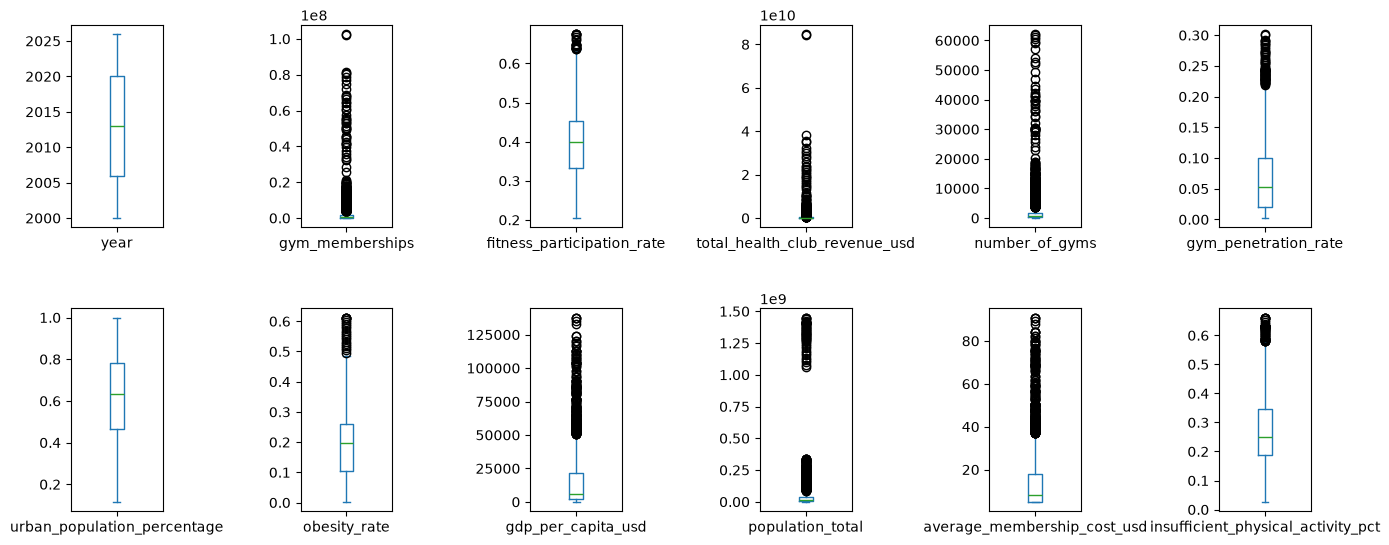

In [2]:
# check distribution
numeric_df = df.select_dtypes(include='number')
numeric_df.plot(
    kind='box', 
    subplots=True, 
    layout=(3, 6), 
    figsize=(16, 10),
    sharex=False, 
    sharey=False
)
plt.subplots_adjust(wspace=1.5, hspace=0.4)
plt.show()

In [3]:
# check for skews
skew = numeric_df.skew()
print(skew)

year                                   0.000000
gym_memberships                        7.629088
fitness_participation_rate             0.223544
total_health_club_revenue_usd         16.718970
number_of_gyms                         6.566614
gym_penetration_rate                   1.137209
urban_population_percentage           -0.338772
obesity_rate                           0.282995
gdp_per_capita_usd                     2.150741
population_total                       6.963572
average_membership_cost_usd            2.266802
insufficient_physical_activity_pct     0.638186
dtype: float64


In [4]:
# apply log transformation for threshold > +1 and < -1
skewed_cols = ['gym_memberships','total_health_club_revenue_usd','number_of_gyms','gym_penetration_rate',
               'gdp_per_capita_usd','population_total','average_membership_cost_usd']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

df

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,Angola,2000,Africa,11.467112,0.3873,15.561446,5.323010,0.005883,0.5051,0.0470,6.336354,16.600205,1.791759,0.2219
1,Angola,2001,Africa,11.550616,0.3939,15.644947,5.407172,0.006181,0.5172,0.0496,6.281493,16.633742,1.791759,0.2192
2,Angola,2002,Africa,11.704322,0.4003,15.798659,5.521461,0.006976,0.5289,0.0522,6.907821,16.667817,1.791759,0.2164
3,Angola,2003,Africa,11.869088,0.4065,15.963424,5.641907,0.007968,0.5400,0.0548,7.034091,16.702750,1.791759,0.2137
4,Angola,2004,Africa,12.098577,0.4124,16.192917,5.786897,0.009653,0.5504,0.0574,7.281022,16.738695,1.791759,0.2110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3559,Zimbabwe,2022,Africa,12.600072,0.3563,16.694414,6.122493,0.018331,0.3871,0.1243,7.838895,16.592406,1.791759,0.1770
3560,Zimbabwe,2023,Africa,12.601498,0.3589,16.695839,6.165418,0.018036,0.3929,0.1243,7.694495,16.609177,1.791759,0.1770
3561,Zimbabwe,2024,Africa,12.704588,0.3616,16.798929,6.232448,0.019607,0.3989,0.1243,7.823327,16.626982,1.791759,0.1770
3562,Zimbabwe,2025,Africa,12.713231,0.3616,16.807572,6.240276,0.019803,0.3989,0.1243,7.823327,16.626982,1.791759,0.1770


In [5]:
# one hot encode region
df = pd.get_dummies(df,columns=['region'],dtype=int)
df

,country,year,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct,region_Africa,region_Asia,region_Europe,region_North America,region_Oceania,region_South America
0,Angola,2000,11.467112,0.3873,15.561446,5.323010,0.005883,0.5051,0.0470,6.336354,16.600205,1.791759,0.2219,1,0,0,0,0,0
1,Angola,2001,11.550616,0.3939,15.644947,5.407172,0.006181,0.5172,0.0496,6.281493,16.633742,1.791759,0.2192,1,0,0,0,0,0
2,Angola,2002,11.704322,0.4003,15.798659,5.521461,0.006976,0.5289,0.0522,6.907821,16.667817,1.791759,0.2164,1,0,0,0,0,0
3,Angola,2003,11.869088,0.4065,15.963424,5.641907,0.007968,0.5400,0.0548,7.034091,16.702750,1.791759,0.2137,1,0,0,0,0,0
4,Angola,2004,12.098577,0.4124,16.192917,5.786897,0.009653,0.5504,0.0574,7.281022,16.738695,1.791759,0.2110,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3559,Zimbabwe,2022,12.600072,0.3563,16.694414,6.122493,0.018331,0.3871,0.1243,7.838895,16.592406,1.791759,0.1770,1,0,0,0,0,0
3560,Zimbabwe,2023,12.601498,0.3589,16.695839,6.165418,0.018036,0.3929,0.1243,7.694495,16.609177,1.791759,0.1770,1,0,0,0,0,0
3561,Zimbabwe,2024,12.704588,0.3616,16.798929,6.232448,0.019607,0.3989,0.1243,7.823327,16.626982,1.791759,0.1770,1,0,0,0,0,0
3562,Zimbabwe,2025,12.713231,0.3616,16.807572,6.240276,0.019803,0.3989,0.1243,7.823327,16.626982,1.791759,0.1770,1,0,0,0,0,0


In [6]:
# aggregate through mean per country
df = df.drop(columns=['year'])
df = df.groupby('country',as_index=False).mean(numeric_only=True)
df

,country,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct,region_Africa,region_Asia,region_Europe,region_North America,region_Oceania,region_South America
0,Albania,11.904311,0.395022,16.532215,5.194231,0.059244,0.522837,0.199926,8.379162,14.828511,2.255719,0.220944,0.0,0.0,1.0,0.0,0.0,0.0
1,Algeria,13.715090,0.437959,17.893131,7.115726,0.024995,0.686019,0.185419,8.327576,17.464410,1.862273,0.266004,1.0,0.0,0.0,0.0,0.0,0.0
2,Angola,13.086185,0.454033,17.208501,6.609288,0.020553,0.619311,0.079359,7.841258,17.065110,1.815321,0.191041,1.0,0.0,0.0,0.0,0.0,0.0
3,Argentina,14.849948,0.459430,19.581834,7.911413,0.068451,0.910978,0.276448,9.132248,17.556945,2.349452,0.362722,0.0,0.0,0.0,0.0,0.0,1.0
4,Armenia,11.563960,0.433022,15.860458,4.727204,0.038269,0.648359,0.220648,8.013598,14.932257,1.964529,0.248952,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Uzbekistan,13.437463,0.396674,17.589899,6.756027,0.024739,0.507215,0.195300,7.282325,17.216032,1.840600,0.204726,0.0,1.0,0.0,0.0,0.0,0.0
128,Venezuela,14.204008,0.412763,18.676621,7.402140,0.052549,0.888815,0.217919,8.514513,17.153973,2.118451,0.417630,0.0,0.0,0.0,0.0,0.0,1.0
129,Vietnam,14.302844,0.300052,18.496039,7.578783,0.021642,0.317415,0.010763,7.471088,18.313591,1.875429,0.236578,0.0,1.0,0.0,0.0,0.0,0.0
130,Zambia,11.915937,0.376359,16.010274,5.667488,0.010549,0.409111,0.060144,6.954362,16.534846,1.791759,0.154752,1.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# reformat encoded columns back to int
encoded = ['region_Africa','region_Asia','region_Europe','region_North America','region_Oceania','region_South America']
df[encoded] = df[encoded].astype('int64')
df

,country,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct,region_Africa,region_Asia,region_Europe,region_North America,region_Oceania,region_South America
0,Albania,11.904311,0.395022,16.532215,5.194231,0.059244,0.522837,0.199926,8.379162,14.828511,2.255719,0.220944,0,0,1,0,0,0
1,Algeria,13.715090,0.437959,17.893131,7.115726,0.024995,0.686019,0.185419,8.327576,17.464410,1.862273,0.266004,1,0,0,0,0,0
2,Angola,13.086185,0.454033,17.208501,6.609288,0.020553,0.619311,0.079359,7.841258,17.065110,1.815321,0.191041,1,0,0,0,0,0
3,Argentina,14.849948,0.459430,19.581834,7.911413,0.068451,0.910978,0.276448,9.132248,17.556945,2.349452,0.362722,0,0,0,0,0,1
4,Armenia,11.563960,0.433022,15.860458,4.727204,0.038269,0.648359,0.220648,8.013598,14.932257,1.964529,0.248952,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Uzbekistan,13.437463,0.396674,17.589899,6.756027,0.024739,0.507215,0.195300,7.282325,17.216032,1.840600,0.204726,0,1,0,0,0,0
128,Venezuela,14.204008,0.412763,18.676621,7.402140,0.052549,0.888815,0.217919,8.514513,17.153973,2.118451,0.417630,0,0,0,0,0,1
129,Vietnam,14.302844,0.300052,18.496039,7.578783,0.021642,0.317415,0.010763,7.471088,18.313591,1.875429,0.236578,0,1,0,0,0,0
130,Zambia,11.915937,0.376359,16.010274,5.667488,0.010549,0.409111,0.060144,6.954362,16.534846,1.791759,0.154752,1,0,0,0,0,0


In [8]:
# drop country column
df = df.drop(columns=['country'])
df

,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct,region_Africa,region_Asia,region_Europe,region_North America,region_Oceania,region_South America
0,11.904311,0.395022,16.532215,5.194231,0.059244,0.522837,0.199926,8.379162,14.828511,2.255719,0.220944,0,0,1,0,0,0
1,13.715090,0.437959,17.893131,7.115726,0.024995,0.686019,0.185419,8.327576,17.464410,1.862273,0.266004,1,0,0,0,0,0
2,13.086185,0.454033,17.208501,6.609288,0.020553,0.619311,0.079359,7.841258,17.065110,1.815321,0.191041,1,0,0,0,0,0
3,14.849948,0.459430,19.581834,7.911413,0.068451,0.910978,0.276448,9.132248,17.556945,2.349452,0.362722,0,0,0,0,0,1
4,11.563960,0.433022,15.860458,4.727204,0.038269,0.648359,0.220648,8.013598,14.932257,1.964529,0.248952,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,13.437463,0.396674,17.589899,6.756027,0.024739,0.507215,0.195300,7.282325,17.216032,1.840600,0.204726,0,1,0,0,0,0
128,14.204008,0.412763,18.676621,7.402140,0.052549,0.888815,0.217919,8.514513,17.153973,2.118451,0.417630,0,0,0,0,0,1
129,14.302844,0.300052,18.496039,7.578783,0.021642,0.317415,0.010763,7.471088,18.313591,1.875429,0.236578,0,1,0,0,0,0
130,11.915937,0.376359,16.010274,5.667488,0.010549,0.409111,0.060144,6.954362,16.534846,1.791759,0.154752,1,0,0,0,0,0


In [9]:
# save to csv
df.to_csv('preprocessed_gym_data.csv',index=False)